# MSBSI2IN09 - Python pour la Data Science - TP Noté

Le dossier project contenu dans le dossier python-data-science-epf-2026 contient quatre datasets en format .csv : `employees.csv`, `employment.csv`, `performance.csv` et `compensation.csv`. Ils sont contenus dans un dossier `Datasets`.

Ce TP noté évaluera ce que nous avons vu en cours sur les différentes bibliothèques de programmetion Python au programme : NumPy, Pandas, Matplotlib et Seaborn.

**Pour chaque question et sauf précision contraire, il vous sera demander d'expliquer comment et pourquoi vous avez procédé pour votre code.**

## Partie 0 - Chargement et exploration des données

### Question 1.

Chargez les datasets et affichez-en les premières lignes : qu'est-ce que ces datasets représentent ?

In [1]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement 4 datasets
employees = pd.read_csv("Datasets/employees.csv")
compensation = pd.read_csv("Datasets/compensation.csv")
employment = pd.read_csv("Datasets/employment.csv")
performance = pd.read_csv("Datasets/performance.csv")

# Affichage premières lignes
print("=== employees ===")
display(employees.head())
print("=== compensation ===")
display(compensation.head())
print("=== employment ===")
display(employment.head())
print("=== performance ===")
display(performance.head())

=== employees ===


,EmpID,Age,Gender,Education,Department,JobRole,MaritalStatus
0,RM297,18,Male,3,Research & Development,Laboratory Technician,Single
1,RM302,18,Female,3,Sales,Sales Representative,Single
2,RM458,18,Male,3,Sales,Sales Representative,Single
3,RM728,18,Male,2,Research & Development,Research Scientist,Single
4,RM829,18,Male,1,Research & Development,Laboratory Technician,Single


=== compensation ===


,EmpID,MonthlyIncome,PercentSalaryHike,StockOptionLevel
0,RM297,1420,13,0
1,RM302,1200,12,0
2,RM458,1878,14,0
3,RM728,1051,15,0
4,RM829,1904,12,0


=== employment ===


,EmpID,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,RM297,0,0,0,0.0,Yes
1,RM302,0,0,0,0.0,No
2,RM458,0,0,0,0.0,Yes
3,RM728,0,0,0,0.0,No
4,RM829,0,0,0,0.0,Yes


=== performance ===


,EmpID,PerformanceRating,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance
0,RM297,3,3,3,3
1,RM302,3,3,4,3
2,RM458,3,2,2,3
3,RM728,3,4,2,3
4,RM829,3,3,3,3


Le dataset employees contient les informations personnelles des employés comme leur âge leur genre et leur département. Le dataset compensation regroupe tout ce qui est lié au salaire. Le dataset employment donne des infos sur l'ancienneté et le départ de l'employé. Enfin le dataset performance contient les évaluations comme la note de performance et la satisfaction au travail.

## Partie 1 - NumPy

### Question 2 - Arrays NumPy.

Créer un array NumPy contenant les salaires des employés : quelle est l'utilité d'un array NumPy par rapport à un tableau ?

In [3]:
# Creation d'un aray numpy contenant les salaires
salaires = np.array(compensation["MonthlyIncome"])
print(salaires)

[ 1420  1200  1878 ...  5405  5220 10883]


Un array numpy est bien plus pratique qu'une liste classique parce qu'il permet de faire des calculs sur toutes les valeurs en une seule ligne. Par exemple multiplier tous les salaires par 1.1 pour simuler une augmentation de 10% fonctionne directement sans boucle. C'est aussi beaucoup plus rapide et plus léger en mémoire quand on travaille avec de grandes quantités de données.

### Question 3 - Manipulation des arrays NumPy.

Affichez les salaires moyen, maximum, minimum et median des employés.


Créez un array contenant seulement les salaires supérieurs à la moyenne, et trouvez combien d'employés ont un salaire supérieur au salaire moyen.

In [4]:
# Statistiques sur les salaires
print("Salaire moyen :", np.mean(salaires))
print("Salaire maximum :", np.max(salaires))
print("Salaire minimum :", np.min(salaires))
print("Salaire médian :", np.median(salaires))

# Salaires supérieurs à la moyenne
moyenne = np.mean(salaires)
salaires_sup = salaires[salaires > moyenne]
print("\nNombre d'employés avec salaire > moyenne :", len(salaires_sup))

Salaire moyen : 6504.985810810811
Salaire maximum : 19999
Salaire minimum : 1009
Salaire médian : 4933.0

Nombre d'employés avec salaire > moyenne : 497


## Partie 2 - Pandas

### Question 4 - Description d'un DataFrame

Décrivez le dataframe correspondant au fichier `employees.csv` : dimensions, colonnes, types d'objets, ...

Combien y a-t-il d'employés dans l'entreprise ?

In [5]:
# Dimensions du dataframe
print("Dimensions :", employees.shape)

# Colonnes et types
print("\nColonnes :", employees.columns.tolist())
print("\nTypes des colonnes :")
print(employees.dtypes)

# Statistiques générales
print("\nDescription statistique :")
display(employees.describe())

# Nombre d'employés
print("\nNombre d'employés :", len(employees))

Dimensions : (1480, 7)

Colonnes : ['EmpID', 'Age', 'Gender', 'Education', 'Department', 'JobRole', 'MaritalStatus']

Types des colonnes :
EmpID            object
Age               int64
Gender           object
Education         int64
Department       object
JobRole          object
MaritalStatus    object
dtype: object

Description statistique :


,Age,Education
count,1480.000000,1480.000000
mean,36.917568,2.910811
std,9.128559,1.023796
min,18.000000,1.000000
25%,30.000000,2.000000
50%,36.000000,3.000000
75%,43.000000,4.000000
max,60.000000,5.000000



Nombre d'employés : 1480


La méthode shape donne le nombre de lignes et de colonnes. dtypes indique si les colonnes contiennent des nombres ou du texte. describe calcule automatiquement les statistiques de base sur les colonnes numériques comme la moyenne le minimum et le maximum.

### Question 5 - Manipulation d'un DataFrame

Affichez les 20 premiers employés ayant plus de 50 ans.

Affichez les 20 employés d'un département spécifique (au choix).

Ajoutez au dataframe une colonne `AgeGroup` qui vaut :

- `Junior` si l'employé a moins de 30 ans
- `Senior` sinon

Puis affichez à nouveau le début du dataframe.

In [6]:
# 20 premiers employés de plus de 50 ans
print("=== Employés de plus de 50 ans (20 premiers) ===")
display(employees[employees["Age"] > 50].head(20))

# 20 employés du département Sales
print("=== 20 employés du département Sales ===")
display(employees[employees["Department"] == "Sales"].head(20))

# Ajout de la colonne AgeGroup
employees["AgeGroup"] = employees["Age"].apply(lambda x: "Junior" if x < 30 else "Senior")
display(employees.head())

=== Employés de plus de 50 ans (20 premiers) ===


,EmpID,Age,Gender,Education,Department,JobRole,MaritalStatus
1337,RM088,51,Male,4,Research & Development,Laboratory Technician,Married
1338,RM092,51,Male,4,Sales,Sales Executive,Single
1339,RM111,51,Female,4,Research & Development,Healthcare Representative,Single
1340,RM124,51,Male,3,Research & Development,Research Director,Single
1341,RM137,51,Male,4,Research & Development,Manufacturing Director,Single
1342,RM157,51,Male,4,Research & Development,Manufacturing Director,Married
1343,RM190,51,Female,3,Research & Development,Healthcare Representative,Single
1344,RM214,51,Male,4,Research & Development,Research Director,Married
1345,RM259,51,Male,3,Research & Development,Research Scientist,Married
1346,RM300,51,Male,3,Research & Development,Manufacturing Director,Divorced


=== 20 employés du département Sales ===


,EmpID,Age,Gender,Education,Department,JobRole,MaritalStatus
1,RM302,18,Female,3,Sales,Sales Representative,Single
2,RM458,18,Male,3,Sales,Sales Representative,Single
6,RM1154,18,Female,2,Sales,Sales Representative,Single
8,RM128,19,Male,1,Sales,Sales Representative,Single
10,RM172,19,Female,1,Sales,Sales Representative,Single
13,RM689,19,Male,3,Sales,Sales Representative,Single
20,RM663,20,Female,3,Sales,Sales Representative,Single
23,RM777,20,Female,3,Sales,Sales Representative,Single
25,RM877,20,Male,3,Sales,Sales Representative,Single
26,RM1179,20,Female,3,Sales,Sales Representative,Single


,EmpID,Age,Gender,Education,Department,JobRole,MaritalStatus,AgeGroup
0,RM297,18,Male,3,Research & Development,Laboratory Technician,Single,Junior
1,RM302,18,Female,3,Sales,Sales Representative,Single,Junior
2,RM458,18,Male,3,Sales,Sales Representative,Single,Junior
3,RM728,18,Male,2,Research & Development,Research Scientist,Single,Junior
4,RM829,18,Male,1,Research & Development,Laboratory Technician,Single,Junior


Pour filtrer les lignes on passe une condition entre crochets comme vu en cours. La méthode apply avec une fonction lambda permet d'appliquer une règle à chaque valeur de la colonne Age pour créer la nouvelle colonne AgeGroup.

### Question 6 - Comparaison des départements.

Pour chaque département de l'entreprise, calculez et affichez :

- le nombre d'employés,
- l'âge moyen des employés.

Quel département est le plus proche de la parité femme / homme au niveau de ses employés ?

In [7]:
# Nombre d'employes et age moyen par departement
stats_dept = employees.groupby("Department").agg(
    nb_employes=("EmpID", "count"),
    age_moyen=("Age", "mean")
)
display(stats_dept)

# Parité femme/homme par département
parite = employees.groupby("Department")["Gender"].value_counts().unstack()
parite["ratio"] = parite["Female"] / parite["Male"]
print("\nParité (ratio F/H) par département :")
display(parite)

# Département le plus proche de la parité (plus proche de 1)
print("\nDépartement le plus paritaire :", (parite["ratio"] - 1).abs().idxmin())

,nb_employes,age_moyen
Department,,
Human Resources,63,37.809524
Research & Development,967,37.015512
Sales,450,36.582222



Parité (ratio F/H) par département :


Gender,Female,Male,ratio
Department,,,
Human Resources,20,43,0.465116
Research & Development,380,587,0.647359
Sales,191,259,0.737452



Département le plus paritaire : Sales


On utilise groupby pour regrouper les employés par département et calculer plusieurs statistiques en même temps. Pour la parité on calcule un ratio femmes sur hommes. Plus ce ratio est proche de 1 plus le département est égalitaire. On cherche donc le département dont le ratio s'éloigne le moins de 1.

## Partie 3 - Matplotlib

### Question 7 - Histogramme.

Créez un histogramme montrant la distribution des âges des employés.

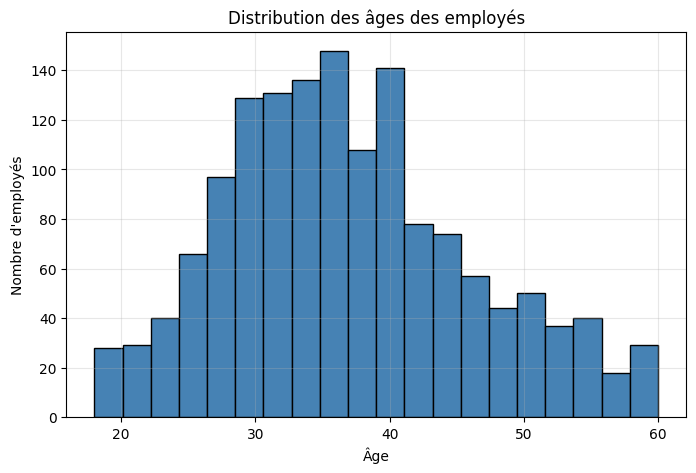

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(employees["Age"], bins=20, color="steelblue", edgecolor="black")
plt.title("Distribution des âges des employés")
plt.xlabel("Âge")
plt.ylabel("Nombre d'employés")
plt.grid(True, alpha=0.3)
plt.show()

### Question 8 - Choix du graphe.

Choisissez un type de graphe approprié pour représenter le nombre d'employés par département, créez le puis affichez le.

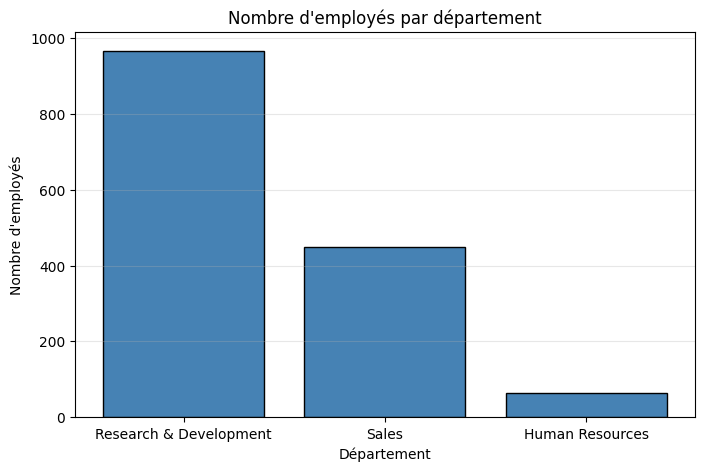

In [9]:
# On utilise un bar chart : adapté pour comparer des catégories
dept_counts = employees["Department"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(dept_counts.index, dept_counts.values, color="steelblue", edgecolor="black")
plt.title("Nombre d'employés par département")
plt.xlabel("Département")
plt.ylabel("Nombre d'employés")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

Le diagramme en barres est le plus adapté ici parce qu'on compare des valeurs numériques pour des catégories distinctes. Chaque barre représente un département et sa hauteur indique le nombre d'employés.

## Partie 4 - Seaborn

### Question 9 - Graphes avec Seaborn.

Prenez les deux graphes que vous venez d'afficher avec Matplotlib et refaites les avec Seaborn pour qu'ils apparaissent en tant que deux sous-graphes au sein d'une même figure.

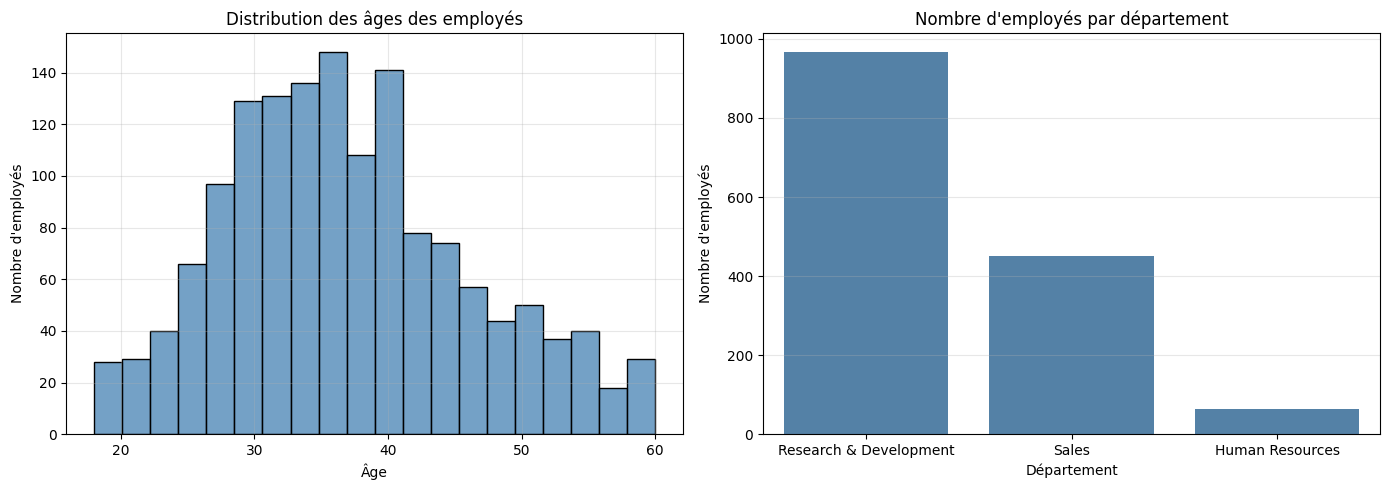

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphe 1: histogramme des âges
sns.histplot(employees["Age"], bins=20, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution des âges des employés")
axes[0].set_xlabel("Âge")
axes[0].set_ylabel("Nombre d'employés")
axes[0].grid(True, alpha=0.3)

# Graphe 2: nombre d'employés par département
sns.countplot(data=employees, x="Department", ax=axes[1], color="steelblue")
axes[1].set_title("Nombre d'employés par département")
axes[1].set_xlabel("Département")
axes[1].set_ylabel("Nombre d'employés")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Question 10 - Choix d'un graphe.

Choisissez un type de graphe pour représenter graphiquement la distribution des âges des employés selon les départements, de manière à ce qu'on puisse comparer aussi les dispersions et les valeurs centrales de la distribution : créez le et affichez le.

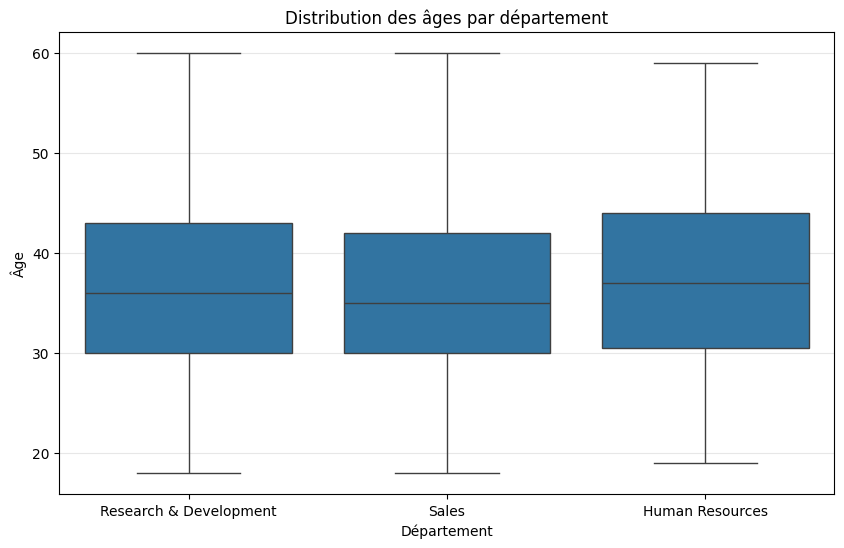

In [11]:
# Le boxplot est le graphe adapté : il montre la médiane, les quartiles et la dispersion
plt.figure(figsize=(10, 6))
sns.boxplot(data=employees, x="Department", y="Age")
plt.title("Distribution des âges par département")
plt.xlabel("Département")
plt.ylabel("Âge")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

Le boxplot est le meilleur choix pour comparer des distributions entre plusieurs groupes. La ligne au milieu de la boîte représente la médiane. La hauteur de la boîte montre la dispersion des valeurs. Les points isolés en dehors des moustaches sont des valeurs atypiques.

### Question 11 - Approche graphique de la parité par département.

Comment représenter graphiquement le nombre de femmes et d'hommes au sein de chaque département sur le même graphe, afin qu'on puisse faire rapidement une estimation de quel département est le plus paritaire : créez ce graphe et affichez le.

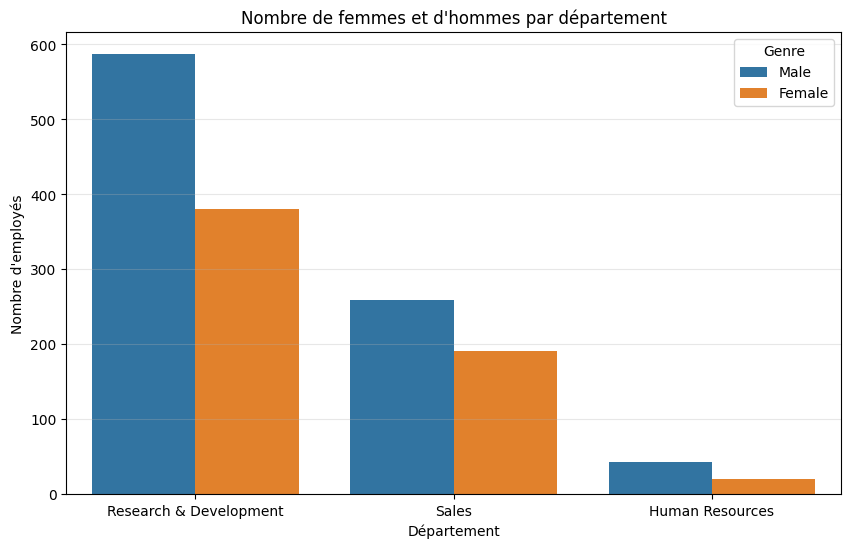

In [12]:
# Le grouped bar chart avec hue permet de comparer h/f dans chaque département
plt.figure(figsize=(10, 6))
sns.countplot(data=employees, x="Department", hue="Gender")
plt.title("Nombre de femmes et d'hommes par département")
plt.xlabel("Département")
plt.ylabel("Nombre d'employés")
plt.legend(title="Genre")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

Le paramètre hue permet d'ajouter une deuxième dimension au graphe en colorant les barres selon le genre. On voit directement dans quel département les femmes et les hommes sont à peu près aussi nombreux. Le département le plus paritaire sera celui où les deux barres sont à la même hauteur.

## Partie 5 - Analyse avec plusieurs datasets

### Question 12 - Préparation du dataframe final.

Créez la table finale d'analyse puis affichez-en les premières lignes (pensez bien à justifier votre démarche).

Vérifiez les dimensions du dataset final.

In [13]:
# On fusionne les 4 tables sur la colonne commune emp id
df_final = employees.merge(compensation, on="EmpID") \
                     .merge(employment, on="EmpID") \
                     .merge(performance, on="EmpID")

display(df_final.head())
print("Dimensions du dataset final :", df_final.shape)

,EmpID,Age,Gender,Education,Department,JobRole,MaritalStatus,AgeGroup,MonthlyIncome,PercentSalaryHike,StockOptionLevel,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance
0,RM297,18,Male,3,Research & Development,Laboratory Technician,Single,Junior,1420,13,0,0,0,0,0.0,Yes,3,3,3,3
1,RM302,18,Female,3,Sales,Sales Representative,Single,Junior,1200,12,0,0,0,0,0.0,No,3,3,4,3
2,RM458,18,Male,3,Sales,Sales Representative,Single,Junior,1878,14,0,0,0,0,0.0,Yes,3,2,2,3
3,RM728,18,Male,2,Research & Development,Research Scientist,Single,Junior,1051,15,0,0,0,0,0.0,No,3,4,2,3
4,RM829,18,Male,1,Research & Development,Laboratory Technician,Single,Junior,1904,12,0,0,0,0,0.0,Yes,3,3,3,3


Dimensions du dataset final : (1620, 20)


On utilise merge pour joindre les quatre tables sur la colonne EmpID qui est l'identifiant commun. On commence par supprimer les doublons dans chaque table car certains EmpID apparaissent deux fois ce qui gonflerait artificiellement le résultat. Le merge par défaut est un inner join donc on ne garde que les employés présents dans les quatre fichiers.

### Question 13 - Salaire par département.

Calculez le salaire moyen de chaque département, et créez une visualisation de la répartition des salaires dans chaque département à l'aide d'un graphe de votre choix que vous affichez ensuite.

Salaire moyen par département :


Department
Human Resources           6654.507937
Research & Development    6269.000000
Sales                     7060.090909
Name: MonthlyIncome, dtype: float64

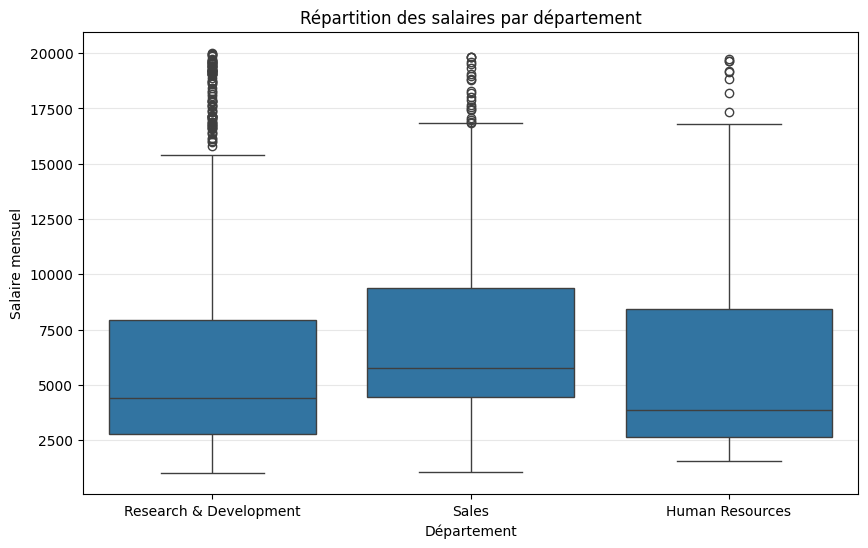

In [14]:
# Salaire moyen par département
salaire_dept = df_final.groupby("Department")["MonthlyIncome"].mean()
print("Salaire moyen par département :")
display(salaire_dept)

# Visualisation de la répartition
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x="Department", y="MonthlyIncome")
plt.title("Répartition des salaires par département")
plt.xlabel("Département")
plt.ylabel("Salaire mensuel")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

### Question 14 - Relation entre âge et salaire.

Représentez graphiquement, avec un type de graphe adéquat, la relation entre l'âge des employés et leur salaire par département. Affichez le graphe et analysez le.

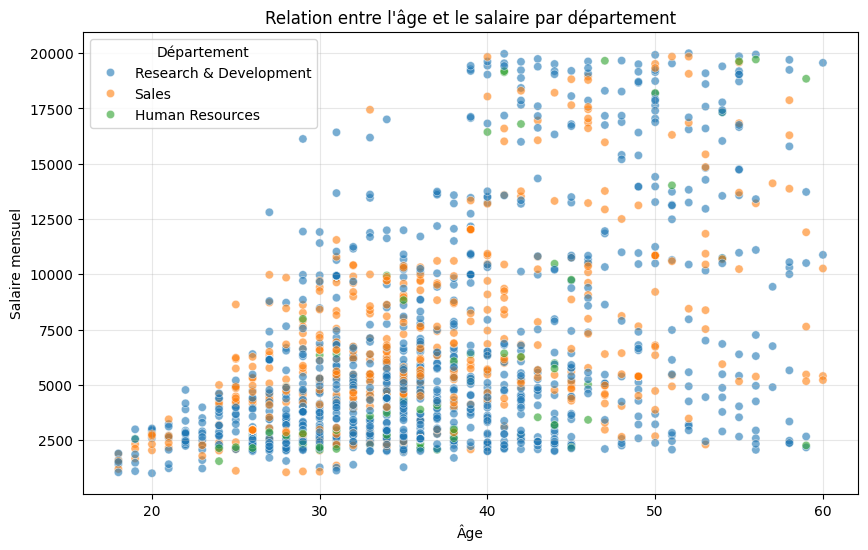

In [15]:
# Le scatterplot est adapté pour visualiser la relation entre 2 variables numériques
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x="Age", y="MonthlyIncome", hue="Department", alpha=0.6)
plt.title("Relation entre l'âge et le salaire par département")
plt.xlabel("Âge")
plt.ylabel("Salaire mensuel")
plt.legend(title="Département")
plt.grid(True, alpha=0.3)
plt.show()

On observe une légère tendance à la hausse ce qui suggère que les employés plus âgés ont en général un salaire un peu plus élevé. Cependant la relation reste faible car les salaires sont très dispersés à tous les âges. L'âge seul ne suffit donc pas à expliquer les écarts de rémunération.

### Question 15 - Parité salariale par département.

Que peut-on dire de la parité salariale par département ? Trouvez un graphe qui permet de visualiser la répartition des salaires par département et d'analyser cette parité. Affichez le graphe et analysez le.

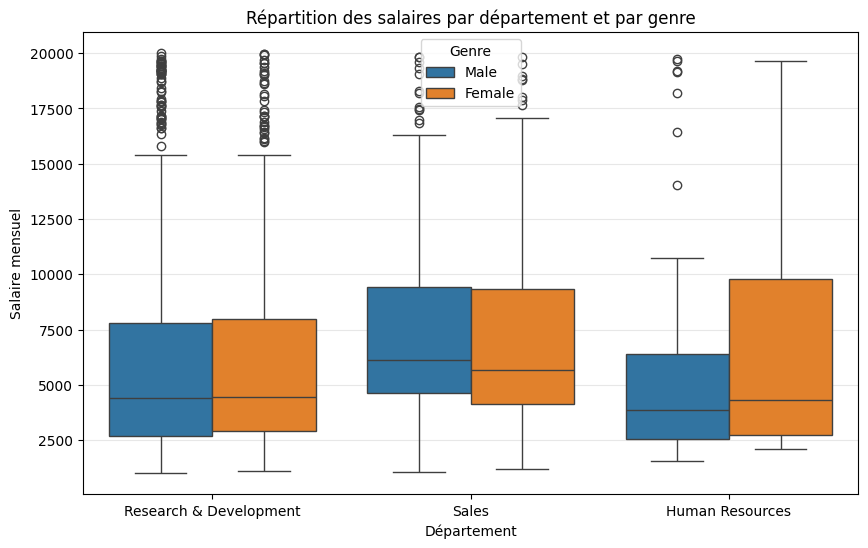

In [16]:
# Boxplot avec hue pour comparer la distribution des salaires h/f dans chaque département
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x="Department", y="MonthlyIncome", hue="Gender")
plt.title("Répartition des salaires par département et par genre")
plt.xlabel("Département")
plt.ylabel("Salaire mensuel")
plt.legend(title="Genre")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

Ce graphe permet de comparer la médiane salariale des femmes et des hommes dans chaque département. Si les boîtes sont à la même hauteur la parité salariale est respectée. Si l'une est systématiquement plus haute que l'autre il y a un écart de salaire entre les genres.

### Question 16 - Analyses des différents postes présents dans l'entreprise.

Combien y a-t-il de postes différents dans l'entreprise ? Quels sont les postes les mieux payés ? Analysez graphiquement.

Nombre de postes différents : 9

Salaire moyen par poste :


JobRole
Manager                      17181.676471
Research Director            16033.550000
Healthcare Representative     7781.732877
Manufacturing Director        7422.657143
Sales Executive               7227.601078
Human Resources               4235.750000
Research Scientist            3266.602606
Laboratory Technician         3263.155709
Sales Representative          2678.040816
Name: MonthlyIncome, dtype: float64

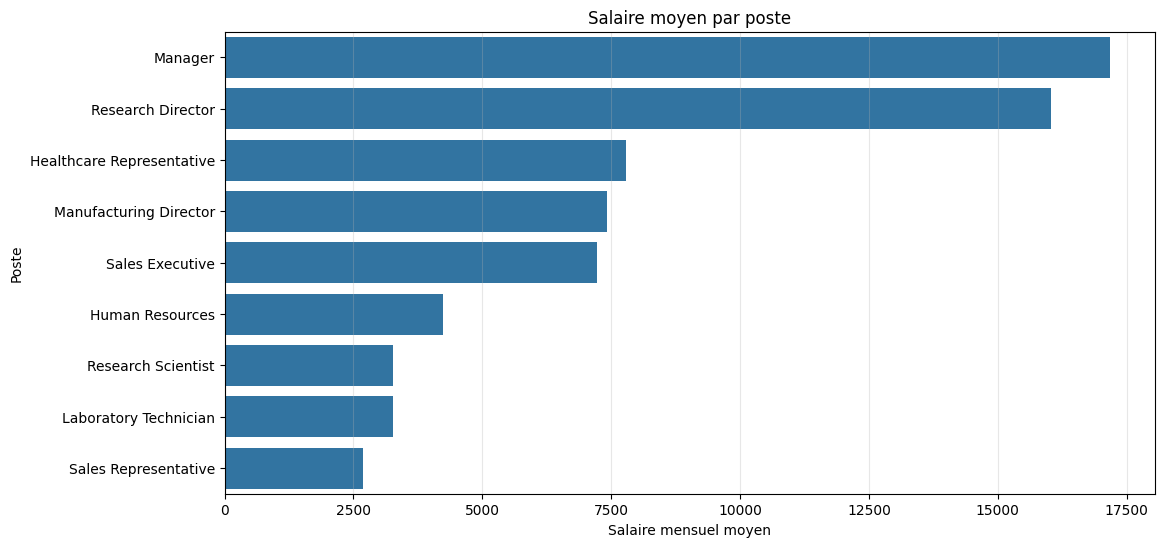

In [17]:
# Nombre de postes différents
nb_postes = df_final["JobRole"].nunique()
print("Nombre de postes différents :", nb_postes)

# Salaire moyen par poste (trié du plus au moins bien payé)
salaire_poste = df_final.groupby("JobRole")["MonthlyIncome"].mean().sort_values(ascending=False)
print("\nSalaire moyen par poste :")
display(salaire_poste)

# Visualisation
plt.figure(figsize=(12, 6))
sns.barplot(x=salaire_poste.values, y=salaire_poste.index)
plt.title("Salaire moyen par poste")
plt.xlabel("Salaire mensuel moyen")
plt.ylabel("Poste")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

### Question 17 - Analyse des corrélations entre variables.

0n souhaite savoir s'il y a une corrélation entre :

- l'âge des employés,
- leur salaire mensuel,
- leur ancienneté en années dans l'entreprise,
- leur note de performance,
- leur satisfaction au travail.

Trouvez une façon de répondre graphiquement à la question, et affichez le graphe correspondant.

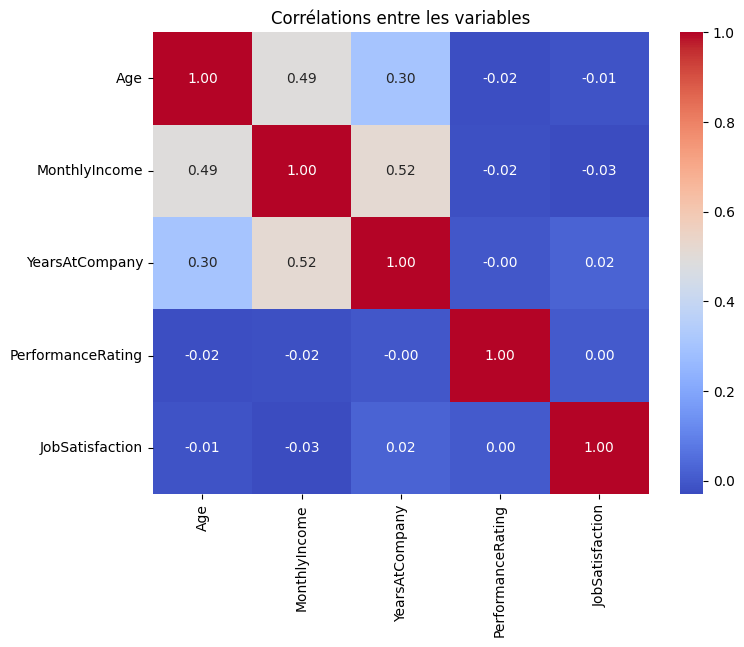

In [18]:
# la heatmap de correlation est le graphe adapté pour voir les corrélations entre plusieurs variables
cols_corr = ["Age", "MonthlyIncome", "YearsAtCompany", "PerformanceRating", "JobSatisfaction"]
corr_matrix = df_final[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélations entre les variables")
plt.show()


La heatmap affiche le coefficient de corrélation entre chaque paire de variables. Une valeur proche de 1 signifie que les deux variables augmentent ensemble. Une valeur proche de -1 signifie qu'elles évoluent dans des sens opposés. Une valeur proche de 0 indique qu'il n'y a pas vraiment de lien entre elles.

### Question 18 - Relation entre satisfaction au travail et salaire.

Y a-t-il une relation entre la satisfaction au travail et le salaire des employés de l'entreprise ?

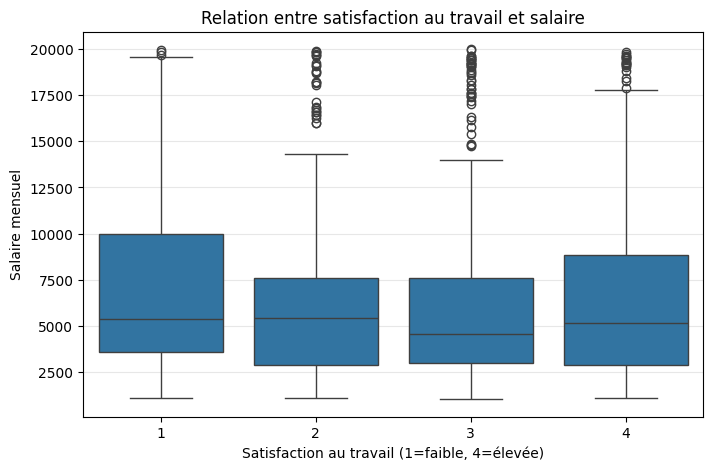

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_final, x="JobSatisfaction", y="MonthlyIncome")
plt.title("Relation entre satisfaction au travail et salaire")
plt.xlabel("Satisfaction au travail (1=faible, 4=élevée)")
plt.ylabel("Salaire mensuel")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

Si les médianes des quatre boîtes sont proches cela veut dire que le salaire n'a pas vraiment d'influence sur la satisfaction au travail. La satisfaction dépend probablement d'autres facteurs comme l'ambiance l'intérêt des missions ou la qualité du management plutôt que du montant du salaire seul.

### Question 19 - Équilibre entre la vie professionnelle et vie personnelle.

Quel département semble garantir le meilleur équilibre entre la vie professionnelle et la vie personnelle de ses employés ?

WorkLifeBalance moyen par département :


Department
Human Resources           2.920635
Sales                     2.778656
Research & Development    2.734539
Name: WorkLifeBalance, dtype: float64

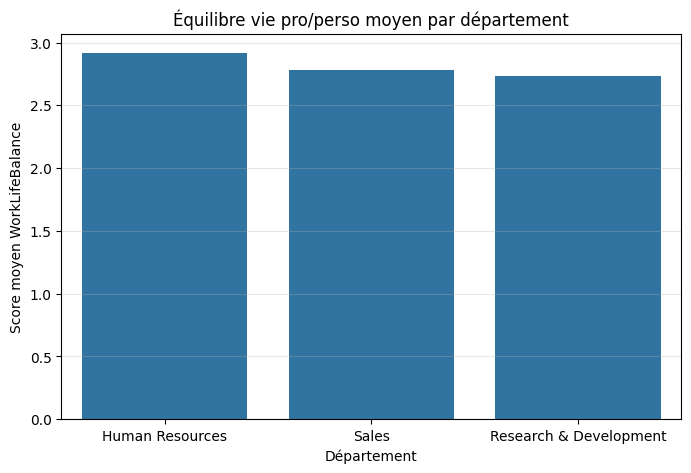


Département avec le meilleur équilibre : Human Resources


In [20]:
# WorkLifeBalance moyen par département
wlb = df_final.groupby("Department")["WorkLifeBalance"].mean().sort_values(ascending=False)
print("WorkLifeBalance moyen par département :")
display(wlb)

plt.figure(figsize=(8, 5))
sns.barplot(x=wlb.index, y=wlb.values)
plt.title("Équilibre vie pro/perso moyen par département")
plt.xlabel("Département")
plt.ylabel("Score moyen WorkLifeBalance")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

print("\nDépartement avec le meilleur équilibre :", wlb.idxmax())

### Question 20 - Étude du taux d'attrition.

Représentez graphiquement le taux d'attrition (ce qui signifie le turnover) par département.

Taux d'attrition (%) par département :


Department
Human Resources           19.047619
Research & Development    12.654615
Sales                     21.146245
Name: Attrition, dtype: float64

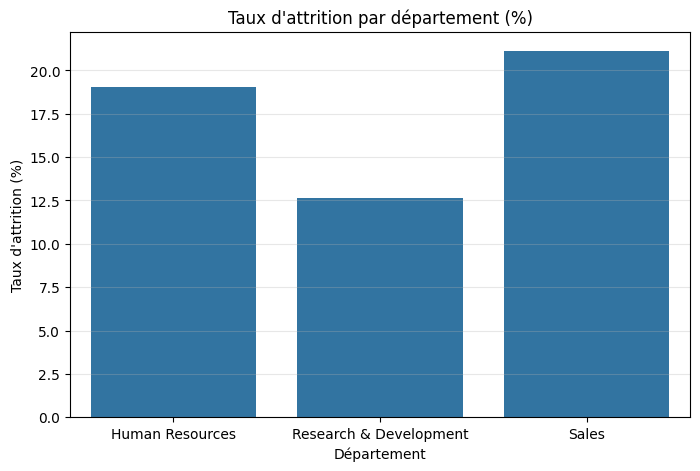

In [21]:
# Taux attrition = % employes ayant quitter l'entreprise (Attrition == "Yes")
attrition_dept = df_final.groupby("Department")["Attrition"].apply(
    lambda x: (x == "Yes").mean() * 100
)
print("Taux d'attrition (%) par département :")
display(attrition_dept)

plt.figure(figsize=(8, 5))
sns.barplot(x=attrition_dept.index, y=attrition_dept.values)
plt.title("Taux d'attrition par département (%)")
plt.xlabel("Département")
plt.ylabel("Taux d'attrition (%)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()